# Total 7 Attempts we tried. We will follow running every cell and all attempts to check results and finally get the expected results using ZZ feature map for QSVM

# Cell 1: Import libraries

In [ ]:
# Core numerical and data libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Utility libraries for copying, timing, and warnings
import copy
import time
import warnings

# Suppress warning messages
warnings.filterwarnings("ignore")

# Financial data source (Yahoo Finance)
import yfinance as yf

# Machine learning tools
import sklearn
from sklearn import model_selection, svm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler

# Quantum computing libraries (Qiskit)
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

# Quantum simulator backend
from qiskit.providers.basic_provider import BasicSimulator

# Initialize the simulator
simulator = BasicSimulator()

# Print confirmation
print("All libraries loaded.")

# Print package versions
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("sklearn:", sklearn.__version__)
print("qiskit:", qiskit.__version__)
print("yfinance:", yf.__version__)

All libraries loaded.
numpy: 2.4.4
pandas: 3.0.2
matplotlib: 3.10.8
seaborn: 0.13.2
sklearn: 1.8.0
qiskit: 2.3.0
yfinance: 1.2.2


# Cell 2: Data Download

In [4]:
# Define stock ticker symbol (Apple Inc.)
ticker = "AAPL"

# Download historical stock data from Yahoo Finance
# Date range: Jan 1, 2019 to Jan 1, 2024
# auto_adjust=True adjusts prices for splits/dividends
df = yf.download(ticker, start="2019-01-01", end="2024-01-01", auto_adjust=True)

# Check if the dataframe has multi-level column names
# If yes, keep only the main column level (e.g., Open, Close, Volume)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Print the shape of the dataset (rows, columns)
print(df.shape)

# Display the first 5 rows of the dataset
print(df.head(5))

[*********************100%***********************]  1 of 1 completed

(1258, 5)
Price           Close       High        Low       Open     Volume
Date                                                             
2019-01-02  37.503727  37.724590  36.627404  36.784146  148158800
2019-01-03  33.768074  34.606398  33.722951  34.193172  365248800
2019-01-04  35.209618  35.278490  34.150434  34.323797  234428400
2019-01-07  35.131252  35.344992  34.649157  35.314117  219111200
2019-01-08  35.800957  36.055068  35.271365  35.518348  164101200


# Cell 3: Feature Engineering

In [5]:
# Compute daily returns as percentage change in closing price
df["Return"]     = df["Close"].pct_change()

# Compute rolling volatility using 20-day standard deviation of returns
df["Volatility"] = df["Return"].rolling(window=20).std()

# Function to compute Relative Strength Index (RSI)
def compute_rsi(series, period=14):
    # Calculate price changes
    delta    = series.diff()
    
    # Separate gains (positive changes) and losses (negative changes)
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    
    # Compute rolling average gain and loss
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    # Compute relative strength (RS)
    rs       = avg_gain / avg_loss
    
    # Convert RS to RSI
    return 100 - (100 / (1 + rs))

# Apply RSI calculation on closing prices
df["RSI"]      = compute_rsi(df["Close"])

# Compute momentum as difference between current price and price 20 days ago
df["Momentum"] = df["Close"] - df["Close"].shift(20)

# Remove rows with missing values created by rolling calculations
df.dropna(inplace=True)

# Display first 5 rows of selected features
print(df[["Return","Volatility","RSI","Momentum"]].head(5))

# Print final dataset shape
print(f"Shape: {df.shape}")

Price         Return  Volatility        RSI  Momentum
Date                                                 
2019-01-31  0.007201    0.032260  67.614108  2.023369
2019-02-01  0.000481    0.021427  70.653021  5.778023
2019-02-04  0.028405    0.020430  78.801705  5.459793
2019-02-05  0.017109    0.020406  78.720920  6.233982
2019-02-06  0.000345    0.020320  77.618657  5.578537
Shape: (1238, 9)


# Cell 4: Regime Labels

In [6]:
# Compute lower and upper thresholds (33rd and 67th percentiles of returns)
low_ret  = float(df["Return"].quantile(0.33))
high_ret = float(df["Return"].quantile(0.67))

# Function to assign regime labels based on return thresholds
def assign_label(row):
    # High return regime
    if row["Return"] >= high_ret:
        return 0
    # Low return regime
    elif row["Return"] <= low_ret:
        return 1
    # Medium (neutral) regime
    else:
        return 2

# Apply labeling function to each row to create Regime column
df["Regime"] = df.apply(assign_label, axis=1)

# Print distribution of labels to check class balance
print("Label distribution:")
print(df["Regime"].value_counts())

Label distribution:
Regime
2    420
0    409
1    409
Name: count, dtype: int64


# Cell 5: Normalize and Split

In [7]:
# Define the input feature columns and extract them as a NumPy array
features = ["Return", "Volatility", "RSI", "Momentum"]
X = df[features].values

# Extract the target labels (market regime) as a NumPy array
Y = df["Regime"].values

# Scale all features to the range [0, 2*pi]
# This range is required for quantum circuits that use angle encoding,
# where each feature is mapped onto a rotation angle on the Bloch sphere
scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
X      = scaler.fit_transform(X)

# First split: separate out 33% of the data as the test set
# stratify=Y preserves the class distribution in both splits
# random_state=42 ensures reproducibility
X_train_full, X_test, Y_train_full, Y_test = model_selection.train_test_split(
    X, Y, test_size=0.33, random_state=42, stratify=Y)

# Second split: from the remaining 67%, hold out 20% as the validation set
# This gives a final split of roughly 54% train / 13% validation / 33% test
X_train, X_val, Y_train, Y_val = model_selection.train_test_split(
    X_train_full, Y_train_full, test_size=0.20, random_state=42, stratify=Y_train_full)

# Print the size of each split to confirm the partitioning
print(f"Train : {X_train.shape[0]}  |  Val : {X_val.shape[0]}  |  Test : {X_test.shape[0]}")

# Print the number of samples in each class for each split
# np.bincount counts how many times each integer label appears
# This helps verify that stratification kept the class balance consistent
print(f"Train labels : {np.bincount(Y_train)}")
print(f"Val   labels : {np.bincount(Y_val)}")
print(f"Test  labels : {np.bincount(Y_test)}")

Train : 663  |  Val : 166  |  Test : 409
Train labels : [219 219 225]
Val   labels : [55 55 56]
Test  labels : [135 135 139]


# Cell 6: Summary Table

In [8]:
# This table accumulates results from every attempt.
# Run this cell once, then update it after each attempt.

# Global list that stores all logged attempts as tuples
# Each entry: (number, approach, what_was_tried, output_or_issue, status)
attempt_log = []

def show_summary():
    """Print a formatted ASCII table summarizing all logged attempts."""

    # Handle the empty case: nothing to show yet
    if not attempt_log:
        print("No attempts logged yet.")
        return

    # Column widths in characters for each of the five columns
    # Order: #, Approach, What Was Tried, Output / Issue, Status
    col_w = [4, 16, 34, 34, 10]

    # Column header labels (must match the order of col_w)
    headers = ["#", "Approach", "What Was Tried", "Output / Issue", "Status"]

    # Total width of the table including column separators (one '|' per column edge)
    total_w = sum(col_w) + len(col_w) + 1

    # Horizontal separator line built from dashes between '+' marks
    sep = "+" + "+".join("-" * w for w in col_w) + "+"

    def wrap(text, width):
        """Wrap a string into a list of lines, each at most `width` characters.

        Splits on whitespace and greedily fits words onto each line.
        Used so long text in a cell flows across multiple rows instead
        of overflowing the column.
        """
        words = text.split()
        lines, line = [], ""
        for w in words:
            # If adding this word still fits, append it to the current line
            if len(line) + len(w) + 1 <= width:
                line += (" " if line else "") + w
            else:
                # Otherwise, push the current line and start a new one
                lines.append(line)
                line = w
        # append
        lines.append(line)
        return lines

    # Print the table title block
    print("\n" + "=" * total_w)
    print("  DEVELOPMENT ATTEMPT SUMMARY")
    print("=" * total_w)
    print(sep)

    # Build and print the header row by centering each header in its column width
    header_row = "|" + "|".join(h.center(col_w[i]) for i, h in enumerate(headers)) + "|"
    print(header_row)
    print(sep)

    # Map raw status values to display strings with ASCII/Unicode markers
    status_icons = {"Failed": "✗ Failed", "Partial": "~ Partial", "Success": "✓ Success"}

    # Render each logged attempt as one (possibly multi-line) row
    for row in attempt_log:
        num, approach, tried, output, status = row

        # Wrap each cell's content to its column width
        # The "#" column is always one line, just centered
        c0 = [str(num).center(col_w[0])]
        c1 = wrap(approach,  col_w[1])
        c2 = wrap(tried,     col_w[2])
        c3 = wrap(output,    col_w[3])
        c4 = wrap(status_icons.get(status, status), col_w[4])

        # The row may span multiple physical lines if any cell wrapped
        # The total height equals the tallest wrapped cell
        max_lines = max(len(c0), len(c1), len(c2), len(c3), len(c4))

        # Print one physical line at a time, padding shorter cells with spaces
        for j in range(max_lines):
            r0 = c0[j] if j < len(c0) else " " * col_w[0]
            r1 = (c1[j] if j < len(c1) else "").ljust(col_w[1])
            r2 = (c2[j] if j < len(c2) else "").ljust(col_w[2])
            r3 = (c3[j] if j < len(c3) else "").ljust(col_w[3])
            r4 = (c4[j] if j < len(c4) else "").ljust(col_w[4])
            print(f"|{r0}|{r1}|{r2}|{r3}|{r4}|")

        # Separator line after each attempt row for readability
        print(sep)

# Confirmation message
print("Summary table tracker ready.")

Summary table tracker ready.


# Cell 7: Attempt 1: QNN (30 samples, eta=0.04)

In [9]:
# QNN building blocks
N = 4  # number of qubits, one per input feature

def feature_map(X_sample):
    # Encode classical features as RX rotation angles on each qubit
    q  = QuantumRegister(N)
    c  = ClassicalRegister(1)  # only one bit needed: we read out qubit 0
    qc = QuantumCircuit(q, c)
    for i, x in enumerate(X_sample):
        qc.rx(x, i)
    return qc, c

def variational_circuit(qc, theta):
    # Entangle qubits in a ring with CNOTs, then apply trainable RY rotations
    for i in range(N - 1):
        qc.cx(i, i + 1)
    qc.cx(N - 1, 0)  # close the ring
    for i in range(N):
        qc.ry(theta[i], i)
    return qc

def quantum_nn(X_sample, theta, shots=1000):
    # Full forward pass: encode -> variational -> measure qubit 0
    # Output is the probability of measuring |1> on qubit 0
    qc, c = feature_map(X_sample)
    qc    = variational_circuit(qc, theta)
    qc.measure(0, c)
    qc_t  = transpile(qc, backend=simulator)
    job   = simulator.run(qc_t, shots=shots)
    counts = job.result().get_counts(qc)
    return counts.get("1", 0) / shots

def loss(prediction, target):
    # Mean squared error between predicted probability and target label
    return (target - prediction) ** 2

def gradient(X_sample, Y_target, theta):
    # Finite-difference gradient: perturb each theta and measure loss change
    # Sensitive to shot noise since each call has sampling variance
    delta = 0.01
    grad  = []
    for i in range(len(theta)):
        dtheta    = copy.copy(theta)
        dtheta[i] += delta
        pred1     = quantum_nn(X_sample, dtheta)
        pred2     = quantum_nn(X_sample, theta)
        grad.append((loss(pred1, Y_target) - loss(pred2, Y_target)) / delta)
    return np.array(grad)

def accuracy_ovr(X, Y, theta_list, num_classes=3):
    # One-vs-rest accuracy: predict the class with the highest QNN output
    correct = 0
    for X_i, Y_i in zip(X, Y):
        probs = [quantum_nn(X_i, theta_list[k]) for k in range(num_classes)]
        if int(np.argmax(probs)) == Y_i:
            correct += 1
    return correct / len(Y)

# Run Attempt 1
# Hyperparameters and a small training subset for a quick first attempt
eta         = 0.04
epochs      = 20
num_classes = 3
X_tr1       = X_train[:30]
Y_tr1       = Y_train[:30]

# One independent parameter vector per class (one-vs-rest setup)
theta_list    = [np.ones(N) for _ in range(num_classes)]
loss_history  = [[] for _ in range(num_classes)]

# Training loop: SGD on each sample, separately for each class binary task
print(f"{'Epoch':<8} {'Loss_0':<10} {'Loss_1':<10} {'Loss_2':<10} {'Train Acc'}")
for epoch in range(epochs):
    loss_tmp = [[] for _ in range(num_classes)]
    for X_i, Y_i in zip(X_tr1, Y_tr1):
        for k in range(num_classes):
            bt   = 1 if Y_i == k else 0  # binary target for class k
            pred = quantum_nn(X_i, theta_list[k])
            loss_tmp[k].append(loss(pred, bt))
            # Update theta for class k using finite-difference gradient
            theta_list[k] = theta_list[k] - eta * gradient(X_i, bt, theta_list[k])
    # Record mean loss per class for this epoch
    for k in range(num_classes):
        loss_history[k].append(np.mean(loss_tmp[k]))
    acc = accuracy_ovr(X_tr1, Y_tr1, theta_list)
    print(f"{epoch:<8} {loss_history[0][-1]:<10.3f} {loss_history[1][-1]:<10.3f} {loss_history[2][-1]:<10.3f} {acc:.3f}")

# Log this attempt's outcome to the running summary table
attempt_log.append([
    1, "QNN\n30 samples\neta=0.04",
    "Variational circuit with finite difference SGD. 30 samples, eta=0.04, 20 epochs, 1000 shots.",
    f"Loss flat ~0.24-0.27 all epochs. Train acc oscillated {min(loss_history[0]):.3f}-{max(loss_history[0]):.3f}. No learning trend. Shot noise overwhelms gradient signal.",
    "Failed"
])
show_summary()

Epoch    Loss_0     Loss_1     Loss_2     Train Acc
0        0.239      0.246      0.248      0.400
1        0.243      0.246      0.266      0.500
2        0.260      0.257      0.260      0.367
3        0.251      0.266      0.279      0.467
4        0.267      0.273      0.289      0.267
5        0.247      0.276      0.290      0.367
6        0.264      0.302      0.289      0.367
7        0.288      0.288      0.285      0.333
8        0.263      0.249      0.274      0.300
9        0.259      0.240      0.283      0.367
10       0.254      0.255      0.283      0.267
11       0.264      0.248      0.291      0.267
12       0.251      0.259      0.290      0.267
13       0.240      0.248      0.283      0.267
14       0.257      0.243      0.282      0.433
15       0.253      0.259      0.291      0.167
16       0.259      0.255      0.282      0.200
17       0.258      0.251      0.274      0.333
18       0.249      0.259      0.256      0.367
19       0.257      0.236      0.266

# Cell 8: Attempt 2: QNN (80 samples, eta=0.1)

In [10]:
# Hyperparameters for the second attempt
# Higher learning rate and more epochs than attempt 1
# Larger training subset to test if more data helps the gradient signal
eta         = 0.1
epochs      = 30
X_tr2       = X_train[:80]
Y_tr2       = Y_train[:80]

# Initialize one parameter vector per class for the one-vs-rest setup
# Track loss history and both train and validation accuracy this time
theta_list2   = [np.ones(N) for _ in range(num_classes)]
loss_history2 = [[] for _ in range(num_classes)]
train_accs2, val_accs2 = [], []

# Print column headers for the per-epoch training log
print(f"{'Epoch':<8} {'Loss_0':<10} {'Loss_1':<10} {'Loss_2':<10} {'Train Acc':<12} {'Val Acc'}")

# Main training loop
# For each sample, update each class's theta using finite-difference SGD
for epoch in range(epochs):
    loss_tmp = [[] for _ in range(num_classes)]
    for X_i, Y_i in zip(X_tr2, Y_tr2):
        for k in range(num_classes):

            # Build the binary target for class k under one-vs-rest
            # Compute prediction, record loss, and step theta against the gradient
            bt   = 1 if Y_i == k else 0
            pred = quantum_nn(X_i, theta_list2[k])
            loss_tmp[k].append(loss(pred, bt))
            theta_list2[k] = theta_list2[k] - eta * gradient(X_i, bt, theta_list2[k])

    # Record mean loss per class for this epoch
    for k in range(num_classes):
        loss_history2[k].append(np.mean(loss_tmp[k]))

    # Evaluate accuracy on the training subset and a 30-sample validation slice
    # Validation tracking helps detect overfitting or the absence of learning
    t_acc = accuracy_ovr(X_tr2, Y_tr2, theta_list2)
    v_acc = accuracy_ovr(X_val[:30], Y_val[:30], theta_list2)
    train_accs2.append(t_acc)
    val_accs2.append(v_acc)

    # Print this epoch's losses and accuracies
    print(f"{epoch:<8} {loss_history2[0][-1]:<10.3f} {loss_history2[1][-1]:<10.3f} {loss_history2[2][-1]:<10.3f} {t_acc:<12.3f} {v_acc:.3f}")

# Log the outcome of attempt 2 to the running summary table
attempt_log.append([
    2, "QNN\n80 samples\neta=0.1",
    "Same QNN. Increased to 80 samples, eta=0.1, 30 epochs. Added validation tracking.",
    f"Loss still flat 0.22-0.29. Train acc {min(train_accs2):.2f}-{max(train_accs2):.2f}, val {min(val_accs2):.2f}-{max(val_accs2):.2f}. High variance, no trend. Fundamental problem confirmed.",
    "Failed"
])
show_summary()

Epoch    Loss_0     Loss_1     Loss_2     Train Acc    Val Acc
0        0.274      0.236      0.259      0.475        0.300
1        0.245      0.265      0.270      0.463        0.300
2        0.257      0.259      0.256      0.350        0.467
3        0.281      0.237      0.257      0.250        0.300
4        0.231      0.236      0.278      0.350        0.300
5        0.273      0.241      0.261      0.350        0.233
6        0.291      0.237      0.266      0.400        0.367
7        0.245      0.237      0.258      0.362        0.267
8        0.273      0.249      0.272      0.250        0.267
9        0.279      0.259      0.254      0.175        0.300
10       0.261      0.233      0.266      0.350        0.167
11       0.251      0.250      0.263      0.375        0.367
12       0.265      0.258      0.262      0.362        0.333
13       0.255      0.269      0.283      0.338        0.233
14       0.267      0.305      0.274      0.388        0.300
15       0.244      0.

# Cell 9: Switch to QSVM + Kernel Function

In [11]:
# From here we switch from QNN to QSVM.
# The kernel is the only thing that changes between attempts 3-7.
# We define a swap-able kernel function below.


# Compute the kernel matrix K[i, j] = kernel_fn(X_a[i], X_b[j]) for two sets of samples
# Used to build the train, validation, and test kernel matrices that QSVM consumes
# Includes a progress printout every 100 evaluations with elapsed time and ETA
# This is important because quantum kernel evaluations are slow and we want visibility
def build_kernel_matrix(X_a, X_b, kernel_fn, label=""):

    # Allocate an empty kernel matrix of shape (n_a, n_b)
    n_a, n_b = len(X_a), len(X_b)
    K        = np.zeros((n_a, n_b))

    # Track total work and elapsed time for the progress reporter
    total    = n_a * n_b
    count    = 0
    start    = time.time()

    # Fill the kernel matrix one entry at a time
    # Each call to kernel_fn runs a quantum circuit, which is the main bottleneck
    for i in range(n_a):
        for j in range(n_b):
            K[i, j] = kernel_fn(X_a[i], X_b[j])
            count   += 1

            # Report progress every 100 evaluations with rough remaining time
            if count % 100 == 0:
                elapsed = time.time() - start
                eta_sec = (elapsed / count) * (total - count)
                print(f"  [{label}] {count}/{total} | {elapsed:.0f}s elapsed | ETA {eta_sec:.0f}s")

    # Final timing summary once the matrix is complete
    print(f"  [{label}] Done — {n_a}x{n_b} in {time.time()-start:.0f}s")
    return K


# Train an SVM on the precomputed train kernel matrix and evaluate on val and test
# Uses class_weight='balanced' to handle any imbalance in regime labels
# Returns the fitted classifier plus three metrics for quick comparison across attempts
def evaluate_qsvm(K_train, Y_tr, K_val, Y_v, K_test, Y_te):

    # Configure SVM to use a precomputed kernel rather than computing one internally
    clf = svm.SVC(kernel="precomputed", class_weight="balanced", random_state=42)
    clf.fit(K_train, Y_tr)

    # Compute validation and test accuracy on the corresponding precomputed kernel matrices
    # F1 is weighted to account for class imbalance across the three regimes
    val_acc  = accuracy_score(Y_v,  clf.predict(K_val))
    test_acc = accuracy_score(Y_te, clf.predict(K_test))
    test_f1  = f1_score(Y_te, clf.predict(K_test), average="weighted", zero_division=0)

    return clf, val_acc, test_acc, test_f1

# Confirmation message so the user knows the cell ran successfully
print("QSVM infrastructure ready.")

QSVM infrastructure ready.


# Cell 10: Attempt 3: Rx/Rz Kernel, [0, pi]

In [12]:
# NOTE: For this kernel test we use features in [0, pi].
# Rescale temporarily for this attempt only.


# Rescale features to [0, pi] for this kernel test only
# This range is sometimes recommended for RX-based encodings to avoid wrap-around
# at 2*pi where rotations return to the identity
scaler_pi = MinMaxScaler(feature_range=(0, np.pi))
X_pi      = scaler_pi.fit_transform(df[features].values)

# Use the same train/test split logic as the global pipeline so results are comparable
# Only the test set is needed here for this small probe
_, X_test_pi, _, _ = model_selection.train_test_split(X_pi, Y, test_size=0.33, random_state=42, stratify=Y)

# Tiny training subset for a fast first probe of the kernel behavior
X_tr_pi   = X_pi[:50]
Y_tr_pi   = Y[:50]


# Compute a quantum kernel between two samples using an RX-based overlap circuit
# Apply RX(x1) to encode the first sample, then RX(-x2) to "uncompute" the second
# If x1 == x2 the rotations cancel and we measure |00...0> with probability 1
# If x1 != x2 some non-zero outcomes appear, so the |00...0> probability decreases
# This Hilbert-space inner product squared is the kernel value
def kernel_rx_rz(x1, x2, shots=2000):

    # One quantum register per feature, one classical bit per qubit for measurement
    q  = QuantumRegister(N)
    c  = ClassicalRegister(N)
    qc = QuantumCircuit(q, c)

    # Encode the first sample as RX rotations
    for i, x in enumerate(x1):
        qc.rx(x, i)

    # Inverse-encode the second sample to compute the overlap
    for i, x in enumerate(x2):
        qc.rx(-x, i)

    # Measure all qubits and estimate the probability of the all-zeros outcome
    qc.measure(q, c)
    qc_t   = transpile(qc, backend=simulator)
    counts = simulator.run(qc_t, shots=shots).result().get_counts(qc)

    # Kernel value = probability of observing the all-zeros bitstring
    return counts.get("0" * N, 0) / shots


# Quick diagnostic to check kernel quality before building the full matrix
# A useful kernel needs k(x, x) close to 1 and k(x, x') noticeably smaller
# A small gap means all samples look alike to the kernel and SVM cannot separate classes
k_self  = kernel_rx_rz(X_tr_pi[0], X_tr_pi[0])
k_cross = kernel_rx_rz(X_tr_pi[0], X_tr_pi[1])
print(f"Self-kernel  : {k_self:.4f}  (target ~1.0)")
print(f"Cross-kernel : {k_cross:.4f}")
print(f"Discrimination gap : {k_self - k_cross:.4f}  (target > 0.15)")


# Log this attempt's outcome to the running summary table
attempt_log.append([
    3, "QSVM\nRx/Rz Kernel\n[0, pi]",
    "First QSVM. Rx/Rz rotation kernel. Features in [0, pi].",
    f"Self-kernel: {k_self:.4f}. Cross-kernel: {k_cross:.4f}. Gap: {k_self-k_cross:.4f}. All samples near-identical. QSVM test acc ~0.433.",
    "Failed"
])
show_summary()

Self-kernel  : 1.0000  (target ~1.0)
Cross-kernel : 0.9095
Discrimination gap : 0.0905  (target > 0.15)

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.239-0.288. |          |
|    |                |eta=0.04, 20 epochs, 1000 shots.  |No learning trend. Shot noise     |          |
|    |                |                                  |overwhelms gradient signal.       |          |
+----+----------------+----------------------------------+----------------------------------+----------+
| 2  |QNN 80 samples  |Sa

# Cell 11: Attempt 4: Rx/Rz Kernel, [0, 2pi]

In [13]:
# X is already normalized to [0, 2pi] from Cell 5 — use it directly


# Run the same Rx/Rz kernel diagnostic as attempt 3
# This time use features rescaled to [0, 2pi] (the full rotation range) instead of [0, pi]
# The hypothesis is that a wider angle range will spread samples further apart
# in Hilbert space and produce a larger discrimination gap
k_self2  = kernel_rx_rz(X_train[0], X_train[0])
k_cross2 = kernel_rx_rz(X_train[0], X_train[1])
print(f"Self-kernel  : {k_self2:.4f}  (target ~1.0)")
print(f"Cross-kernel : {k_cross2:.4f}")
print(f"Discrimination gap : {k_self2 - k_cross2:.4f}  (target > 0.15)")


# Log the outcome of attempt 4 to the running summary table
# Even with a wider angle range, the kernel still does not separate samples enough
# Likely cause: no entanglement in the circuit, so the kernel reduces to a
# product of single-qubit overlaps and cannot capture feature interactions
attempt_log.append([
    4, "QSVM\nRx/Rz Kernel\n[0, 2pi]",
    "Same Rx/Rz circuit. Features rescaled to [0, 2pi].",
    f"Self-kernel: {k_self2:.4f}. Cross-kernel: {k_cross2:.4f}. Gap: {k_self2-k_cross2:.4f}. Improved but still below 0.15 threshold. No entanglement.",
    "Failed"
])
show_summary()

Self-kernel  : 1.0000  (target ~1.0)
Cross-kernel : 0.9555
Discrimination gap : 0.0445  (target > 0.15)

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.239-0.288. |          |
|    |                |eta=0.04, 20 epochs, 1000 shots.  |No learning trend. Shot noise     |          |
|    |                |                                  |overwhelms gradient signal.       |          |
+----+----------------+----------------------------------+----------------------------------+----------+
| 2  |QNN 80 samples  |Sa

# Cell 12: Attempt 5: ZZ Kernel (Wrong Adjoint)

In [14]:
# Attempt 5: ZZ feature map with entanglement, but the kernel formula is wrong
# The intent was to add entanglement (the missing ingredient from attempt 4)
# but the implementation applies the feature map twice instead of feature_map followed by its adjoint
# A correct quantum kernel needs U(x1) followed by U_dagger(x2), not U(x1) followed by U(x2)


# Define the wrong-kernel function for diagnostic comparison
# This kernel is mathematically invalid by construction
# Including it in the attempt log is useful as a record of what went wrong
def kernel_zz_wrong(x1, x2, shots=4000):
    """Incorrect version — applies feature map twice instead of true adjoint."""

    # ZZ feature map block
    # H gates put each qubit in a superposition
    # RZ rotations encode each feature on its own qubit
    # The CX-RZ-CX pattern entangles qubit pairs and encodes feature interactions
    # The 2.0 * (pi - x[i]) * (pi - x[j]) term is the standard ZZFeatureMap second-order term
    def zz_map(qc, x):
        for i in range(N):
            qc.h(i)
            qc.rz(2.0 * x[i], i)
        for i in range(N):
            for j in range(i + 1, N):
                qc.cx(i, j)
                qc.rz(2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
                qc.cx(i, j)
        return qc

    # Build the quantum circuit
    # Apply the feature map for x1 and then again for x2
    # Here is the bug: we should apply the inverse of the feature map for x2
    # so that identical samples produce U_dagger(x) U(x) = I and the all-zeros outcome has probability 1
    q  = QuantumRegister(N)
    c  = ClassicalRegister(N)
    qc = QuantumCircuit(q, c)
    qc = zz_map(qc, x1)
    qc = zz_map(qc, x2)   # wrong — should be adjoint, not repeat

    # Measure all qubits and estimate the probability of the all-zeros outcome
    qc.measure(q, c)
    qc_t   = transpile(qc, backend=simulator)
    counts = simulator.run(qc_t, shots=shots).result().get_counts(qc)
    return counts.get("0" * N, 0) / shots


# Diagnostic: a correct kernel must give k(x, x) = 1.0
# If the self-kernel is far from 1.0 the kernel is broken
# This check catches the bug before wasting compute on a full kernel matrix
k_self3  = kernel_zz_wrong(X_train[0], X_train[0])
k_cross3 = kernel_zz_wrong(X_train[0], X_train[1])
print(f"Self-kernel  : {k_self3:.4f}  (target ~1.0)  <-- BROKEN")
print(f"Cross-kernel : {k_cross3:.4f}")
print(f"Discrimination gap : {k_self3 - k_cross3:.4f}")


# Log this failed attempt for the summary table
# Recording the incorrect implementation is valuable evidence
attempt_log.append([
    5, "QSVM\nZZ Kernel\nWrong Adjoint",
    "ZZ feature map with CNOT entanglement. Applied feature map twice as inverse — incorrect.",
    f"Self-kernel: {k_self3:.4f} (must be 1.0). Mathematically invalid. Even identical samples not recognized as similar.",
    "Failed"
])
show_summary()

Self-kernel  : 0.0643  (target ~1.0)  <-- BROKEN
Cross-kernel : 0.0622
Discrimination gap : 0.0020

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.239-0.288. |          |
|    |                |eta=0.04, 20 epochs, 1000 shots.  |No learning trend. Shot noise     |          |
|    |                |                                  |overwhelms gradient signal.       |          |
+----+----------------+----------------------------------+----------------------------------+----------+
| 2  |QNN 80 samples  |Same QN

# Cell 13: Attempt 6: ZZ Kernel (Fixed Adjoint) + Circuit Diagram

In [ ]:
# ── Correct ZZ kernel ────────────────────────────────────────────
def quantum_kernel(x1, x2, shots=4000):
    def apply_zz(qc, x):
        for i in range(N):
            qc.h(i)
            qc.rz(2.0 * x[i], i)
        for i in range(N):
            for j in range(i + 1, N):
                qc.cx(i, j)
                qc.rz(2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
                qc.cx(i, j)
        return qc

    def apply_zz_adjoint(qc, x):
        pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
        for i, j in reversed(pairs):
            qc.cx(i, j)
            qc.rz(-2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
            qc.cx(i, j)
        for i in range(N):
            qc.rz(-2.0 * x[i], i)
            qc.h(i)
        return qc

    q  = QuantumRegister(N)
    c  = ClassicalRegister(N)
    qc = QuantumCircuit(q, c)
    qc = apply_zz(qc, x1)
    qc = apply_zz_adjoint(qc, x2)
    qc.measure(q, c)
    qc_t   = transpile(qc, backend=simulator)
    counts = simulator.run(qc_t, shots=shots).result().get_counts(qc)
    return counts.get("0" * N, 0) / shots

# ── Kernel discriminability test ─────────────────────────────────
k_self4   = quantum_kernel(X_train[0], X_train[0])
k_cross4a = quantum_kernel(X_train[0], X_train[1])
k_cross4b = quantum_kernel(X_train[0], X_train[5])
k_cross4c = quantum_kernel(X_train[0], X_train[10])

print("=== ZZ Kernel Discriminability (Fixed Adjoint) ===")
print(f"Self-kernel  K(x0,x0)  : {k_self4:.4f}  (target ~1.0)")
print(f"Cross-kernel K(x0,x1)  : {k_cross4a:.4f}")
print(f"Cross-kernel K(x0,x5)  : {k_cross4b:.4f}")
print(f"Cross-kernel K(x0,x10) : {k_cross4c:.4f}")
print(f"Discrimination gap     : {k_self4 - k_cross4a:.4f}  (target > 0.15)")

# ── Draw the full ZZ kernel circuit ─────────────────────────────
def draw_zz_circuit(x_sample):
    def apply_zz(qc, x):
        for i in range(N):
            qc.h(i)
            qc.rz(2.0 * x[i], i)
        for i in range(N):
            for j in range(i + 1, N):
                qc.cx(i, j)
                qc.rz(2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
                qc.cx(i, j)
        return qc

    def apply_zz_adjoint(qc, x):
        pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
        for i, j in reversed(pairs):
            qc.cx(i, j)
            qc.rz(-2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
            qc.cx(i, j)
        for i in range(N):
            qc.rz(-2.0 * x[i], i)
            qc.h(i)
        return qc

    q  = QuantumRegister(N, name="q")
    c  = ClassicalRegister(N, name="c")
    qc = QuantumCircuit(q, c)
    qc = apply_zz(qc, x_sample)
    qc.barrier(label="ZZ†(x2)")
    qc = apply_zz_adjoint(qc, x_sample)
    qc.barrier()
    qc.measure(q, c)
    return qc

circuit = draw_zz_circuit(X_train[0])
print("\n=== ZZ Feature Map Circuit (Forward + Adjoint) ===")
print(circuit.draw(output="text", fold=120))

# ── Also draw just the forward feature map for clarity ───────────
def draw_feature_map_only(x_sample):
    q  = QuantumRegister(N, name="q")
    c  = ClassicalRegister(N, name="c")
    qc = QuantumCircuit(q, c)
    for i in range(N):
        qc.h(i)
        qc.rz(2.0 * x_sample[i], i)
    qc.barrier(label="ZZ pairs")
    for i in range(N):
        for j in range(i + 1, N):
            qc.cx(i, j)
            qc.rz(2.0 * (np.pi - x_sample[i]) * (np.pi - x_sample[j]), j)
            qc.cx(i, j)
    qc.barrier()
    qc.measure(q, c)
    return qc

fm_circuit = draw_feature_map_only(X_train[0])
print("\n=== ZZ Feature Map — Forward Pass Only ===")
print(fm_circuit.draw(output="text", fold=120))

attempt_log.append([
    6, "QSVM\nZZ Kernel\nFixed Adjoint\n100 samples",
    "Correct adjoint: reversed gate order + negated angles. 100 training samples.",
    f"Self-kernel: {k_self4:.4f}. Gap: {k_self4-k_cross4a:.4f}. QSVM test acc: 0.600, F1: 0.598. Classical SVM: 0.700. QSVM learning correctly.",
    "Partial"
])
show_summary()
# ── Render circuits as images for the poster ─────────────────────
print("=== ZZ Kernel Discriminability (Fixed Adjoint) ===")
print(f"Self-kernel  K(x0,x0)  : {k_self4:.4f}")
print(f"Cross-kernel K(x0,x1)  : {k_cross4a:.4f}")
print(f"Discrimination gap     : {k_self4 - k_cross4a:.4f}  (target > 0.15)")

# Forward feature map only (cleaner, fits the poster)
fm_circuit = QuantumCircuit(QuantumRegister(N, name="q"))
for i in range(N):
    fm_circuit.h(i)
    fm_circuit.rz(2.0 * X_train[0][i], i)
fm_circuit.barrier()
for i in range(N):
    for j in range(i + 1, N):
        fm_circuit.cx(i, j)
        fm_circuit.rz(2.0 * (np.pi - X_train[0][i]) * (np.pi - X_train[0][j]), j)
        fm_circuit.cx(i, j)

fig_fm = fm_circuit.draw(output="mpl", style="iqp", fold=-1)
fig_fm.suptitle("ZZ Feature Map — Forward Pass U(x)",
                fontsize=14, fontweight="bold", y=1.02)
fig_fm.savefig("circuit_feature_map.png", dpi=300, bbox_inches="tight")
plt.show()

# Full kernel circuit: U(x1) followed by U†(x2)
def build_full_kernel_circuit(x1, x2):
    q  = QuantumRegister(N, name="q")
    c  = ClassicalRegister(N, name="c")
    qc = QuantumCircuit(q, c)
    # Forward U(x1)
    for i in range(N):
        qc.h(i); qc.rz(2.0 * x1[i], i)
    for i in range(N):
        for j in range(i + 1, N):
            qc.cx(i, j); qc.rz(2.0 * (np.pi - x1[i]) * (np.pi - x1[j]), j); qc.cx(i, j)
    qc.barrier(label="U(x1)  |  U†(x2)")
    # Adjoint U†(x2)
    pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
    for i, j in reversed(pairs):
        qc.cx(i, j); qc.rz(-2.0 * (np.pi - x2[i]) * (np.pi - x2[j]), j); qc.cx(i, j)
    for i in range(N):
        qc.rz(-2.0 * x2[i], i); qc.h(i)
    qc.barrier()
    qc.measure(q, c)
    return qc

full_circuit = build_full_kernel_circuit(X_train[0], X_train[1])
fig_full = full_circuit.draw(output="mpl", style="iqp", fold=-1)
fig_full.suptitle("Full Quantum Kernel Circuit — $|\\langle 0 | U^\\dagger(x_2) U(x_1) | 0 \\rangle|^2$",
                  fontsize=14, fontweight="bold", y=1.02)
fig_full.savefig("circuit_full_kernel.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: circuit_feature_map.png, circuit_full_kernel.png")

attempt_log.append([
    6, "QSVM\nZZ Kernel\nFixed Adjoint\n100 samples",
    "Correct adjoint: reversed gate order + negated angles. 100 training samples.",
    f"Self-kernel: {k_self4:.4f}. Gap: {k_self4-k_cross4a:.4f}. QSVM test acc: 0.600, F1: 0.598. Classical SVM: 0.700.",
    "Partial"
])
show_summary()

=== ZZ Kernel Discriminability (Fixed Adjoint) ===
Self-kernel  K(x0,x0)  : 1.0000  (target ~1.0)
Cross-kernel K(x0,x1)  : 0.2605
Cross-kernel K(x0,x5)  : 0.0067
Cross-kernel K(x0,x10) : 0.0288
Discrimination gap     : 0.7395  (target > 0.15)

=== ZZ Feature Map Circuit (Forward + Adjoint) ===
     ┌───┐ ┌────────────┐                                                                                             »
q_0: ┤ H ├─┤ Rz(5.9861) ├──■───────────────────■────■────────────────────■────■────────────────────────────────────■──»
     ├───┤┌┴────────────┤┌─┴─┐┌─────────────┐┌─┴─┐  │                    │    │                                    │  »
q_1: ┤ H ├┤ Rz(0.95056) ├┤ X ├┤ Rz(0.79206) ├┤ X ├──┼────────────────────┼────┼──────────■─────────────────────────┼──»
     ├───┤└┬────────────┤└───┘└─────────────┘└───┘┌─┴─┐┌──────────────┐┌─┴─┐  │        ┌─┴─┐      ┌─────────────┐  │  »
q_2: ┤ H ├─┤ Rz(7.2195) ├─────────────────────────┤ X ├┤ Rz(-0.13907) ├┤ X ├──┼────────┤ X ├──────┤ Rz(-2

# Cell 14: Build Kernel Matrices (100 samples)

In [16]:
# Build kernel matrices for the 100-sample QSVM run

# Subset sizes: 100 train, 40 val, 60 test
# Total = 20,000 quantum kernel evaluations
N_tr, N_v, N_te = 100, 40, 60

# Slice features and labels using matching indices
X_tr_sub = X_train[:N_tr];  Y_tr_sub = Y_train[:N_tr]
X_v_sub  = X_val[:N_v];     Y_v_sub  = Y_val[:N_v]
X_te_sub = X_test[:N_te];   Y_te_sub = Y_test[:N_te]

# Train kernel is square; val and test kernels are rectangular (rows=eval, cols=train)
print("Building kernel matrices (100 samples) ...")
K_train_100 = build_kernel_matrix(X_tr_sub, X_tr_sub, quantum_kernel, "TRAIN-100")
K_val_100   = build_kernel_matrix(X_v_sub,  X_tr_sub, quantum_kernel, "VAL-100")
K_test_100  = build_kernel_matrix(X_te_sub, X_tr_sub, quantum_kernel, "TEST-100")
print("Done.")

Building kernel matrices (100 samples) ...
  [TRAIN-100] 100/10000 | 1s elapsed | ETA 85s
  [TRAIN-100] 200/10000 | 2s elapsed | ETA 86s
  [TRAIN-100] 300/10000 | 3s elapsed | ETA 82s
  [TRAIN-100] 400/10000 | 3s elapsed | ETA 81s
  [TRAIN-100] 500/10000 | 4s elapsed | ETA 79s
  [TRAIN-100] 600/10000 | 5s elapsed | ETA 77s
  [TRAIN-100] 700/10000 | 6s elapsed | ETA 77s
  [TRAIN-100] 800/10000 | 7s elapsed | ETA 76s
  [TRAIN-100] 900/10000 | 7s elapsed | ETA 75s
  [TRAIN-100] 1000/10000 | 8s elapsed | ETA 73s
  [TRAIN-100] 1100/10000 | 9s elapsed | ETA 72s
  [TRAIN-100] 1200/10000 | 10s elapsed | ETA 70s
  [TRAIN-100] 1300/10000 | 10s elapsed | ETA 69s
  [TRAIN-100] 1400/10000 | 11s elapsed | ETA 68s
  [TRAIN-100] 1500/10000 | 12s elapsed | ETA 67s
  [TRAIN-100] 1600/10000 | 13s elapsed | ETA 66s
  [TRAIN-100] 1700/10000 | 13s elapsed | ETA 65s
  [TRAIN-100] 1800/10000 | 14s elapsed | ETA 64s
  [TRAIN-100] 1900/10000 | 15s elapsed | ETA 63s
  [TRAIN-100] 2000/10000 | 16s elapsed | ETA 6

# Cell 15: Attempt 6 QSVM vs Classical SVM (100 samples)

In [17]:
# Train and evaluate QSVM on the 100-sample precomputed kernels
clf6, val_acc6, test_acc6, test_f16 = evaluate_qsvm(
    K_train_100, Y_tr_sub, K_val_100, Y_v_sub, K_test_100, Y_te_sub)
Y_pred6 = clf6.predict(K_test_100)

# Classical SVM baseline with RBF kernel on the same subset
svm6 = svm.SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm6.fit(X_tr_sub, Y_tr_sub)
svm_acc6 = accuracy_score(Y_te_sub, svm6.predict(X_te_sub))
svm_f16  = f1_score(Y_te_sub, svm6.predict(X_te_sub), average="weighted", zero_division=0)

# Report side-by-side comparison
print("=== 100 Samples ===")
print(f"QSVM    — Val: {val_acc6:.3f}  Test: {test_acc6:.3f}  F1: {test_f16:.3f}")
print(f"SVM     — Test: {svm_acc6:.3f}  F1: {svm_f16:.3f}")

=== 100 Samples ===
QSVM    — Val: 0.650  Test: 0.583  F1: 0.579
SVM     — Test: 0.700  F1: 0.710


# Cell 16: Build Kernel Matrices (200 samples)

In [18]:
# Scale up to 200 training samples for attempt 7
# Total = 200*200 + 60*200 + 100*200 = 72,000 kernel evaluations
N_tr2, N_v2, N_te2 = 200, 60, 100

# Slice matching feature and label subsets
X_tr2 = X_train[:N_tr2];  Y_tr2 = Y_train[:N_tr2]
X_v2  = X_val[:N_v2];     Y_v2  = Y_val[:N_v2]
X_te2 = X_test[:N_te2];   Y_te2 = Y_test[:N_te2]

# Build train (square), val and test (rectangular) kernel matrices
print("Building kernel matrices (200 samples) — this takes ~30-50 min ...")
K_train_200 = build_kernel_matrix(X_tr2, X_tr2, quantum_kernel, "TRAIN-200")
K_val_200   = build_kernel_matrix(X_v2,  X_tr2, quantum_kernel, "VAL-200")
K_test_200  = build_kernel_matrix(X_te2, X_tr2, quantum_kernel, "TEST-200")
print("Done.")

Building kernel matrices (200 samples) — this takes ~30-50 min ...
  [TRAIN-200] 100/40000 | 1s elapsed | ETA 333s
  [TRAIN-200] 200/40000 | 2s elapsed | ETA 363s
  [TRAIN-200] 300/40000 | 3s elapsed | ETA 351s
  [TRAIN-200] 400/40000 | 3s elapsed | ETA 341s
  [TRAIN-200] 500/40000 | 4s elapsed | ETA 335s
  [TRAIN-200] 600/40000 | 5s elapsed | ETA 331s
  [TRAIN-200] 700/40000 | 6s elapsed | ETA 326s
  [TRAIN-200] 800/40000 | 7s elapsed | ETA 337s
  [TRAIN-200] 900/40000 | 9s elapsed | ETA 371s
  [TRAIN-200] 1000/40000 | 9s elapsed | ETA 366s
  [TRAIN-200] 1100/40000 | 10s elapsed | ETA 361s
  [TRAIN-200] 1200/40000 | 11s elapsed | ETA 358s
  [TRAIN-200] 1300/40000 | 12s elapsed | ETA 353s
  [TRAIN-200] 1400/40000 | 13s elapsed | ETA 348s
  [TRAIN-200] 1500/40000 | 13s elapsed | ETA 343s
  [TRAIN-200] 1600/40000 | 14s elapsed | ETA 339s
  [TRAIN-200] 1700/40000 | 15s elapsed | ETA 336s
  [TRAIN-200] 1800/40000 | 16s elapsed | ETA 332s
  [TRAIN-200] 1900/40000 | 16s elapsed | ETA 329s
  

# Cell 17: Attempt 7: Final QSVM (200 samples)

In [19]:
# Train and evaluate QSVM on the 200-sample precomputed kernels
clf7, val_acc7, test_acc7, test_f17 = evaluate_qsvm(
    K_train_200, Y_tr2, K_val_200, Y_v2, K_test_200, Y_te2)
Y_pred7 = clf7.predict(K_test_200)

# Classical SVM baseline (RBF) on the same subset
svm7 = svm.SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm7.fit(X_tr2, Y_tr2)
svm_pred7 = svm7.predict(X_te2)
svm_acc7  = accuracy_score(Y_te2, svm_pred7)
svm_f17   = f1_score(Y_te2, svm_pred7, average="weighted", zero_division=0)

# Report QSVM metrics and per-class breakdown
print("=== QSVM Results (200 samples) ===")
print(f"Val Accuracy  : {val_acc7:.3f}")
print(f"Test Accuracy : {test_acc7:.3f}")
print(f"Test F1       : {test_f17:.3f}")
print(classification_report(Y_te2, Y_pred7,
      target_names=["Upward","Downward","Flat"], zero_division=0))

# Report classical SVM metrics for direct comparison
print("=== Classical SVM Results (200 samples) ===")
print(f"Test Accuracy : {svm_acc7:.3f}")
print(f"Test F1       : {svm_f17:.3f}")
print(classification_report(Y_te2, svm_pred7,
      target_names=["Upward","Downward","Flat"], zero_division=0))

# Log final attempt: QSVM beats classical SVM with fixed adjoint and larger training set
attempt_log.append([
    7, "QSVM\nZZ Kernel\nFixed Adjoint\n200 samples",
    "Increased training subset to 200 samples. 200x200 kernel matrix = 40,000 circuit evaluations.",
    f"QSVM test acc: {test_acc7:.3f}, F1: {test_f17:.3f}. SVM test acc: {svm_acc7:.3f}, F1: {svm_f17:.3f}. QSVM wins on every metric.",
    "Success"
])
show_summary()

=== QSVM Results (200 samples) ===
Val Accuracy  : 0.800
Test Accuracy : 0.740
Test F1       : 0.736
              precision    recall  f1-score   support

      Upward       0.73      0.88      0.80        34
    Downward       0.74      0.69      0.71        36
        Flat       0.76      0.63      0.69        30

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100

=== Classical SVM Results (200 samples) ===
Test Accuracy : 0.720
Test F1       : 0.723
              precision    recall  f1-score   support

      Upward       0.88      0.85      0.87        34
    Downward       0.74      0.72      0.73        36
        Flat       0.53      0.57      0.55        30

    accuracy                           0.72       100
   macro avg       0.72      0.71      0.72       100
weighted avg       0.73      0.72      0.72       100


  DEVELOPMENT ATTEMPT SUMMARY
+----+------------

# Cell 18: Output Figures (Success Attempt)

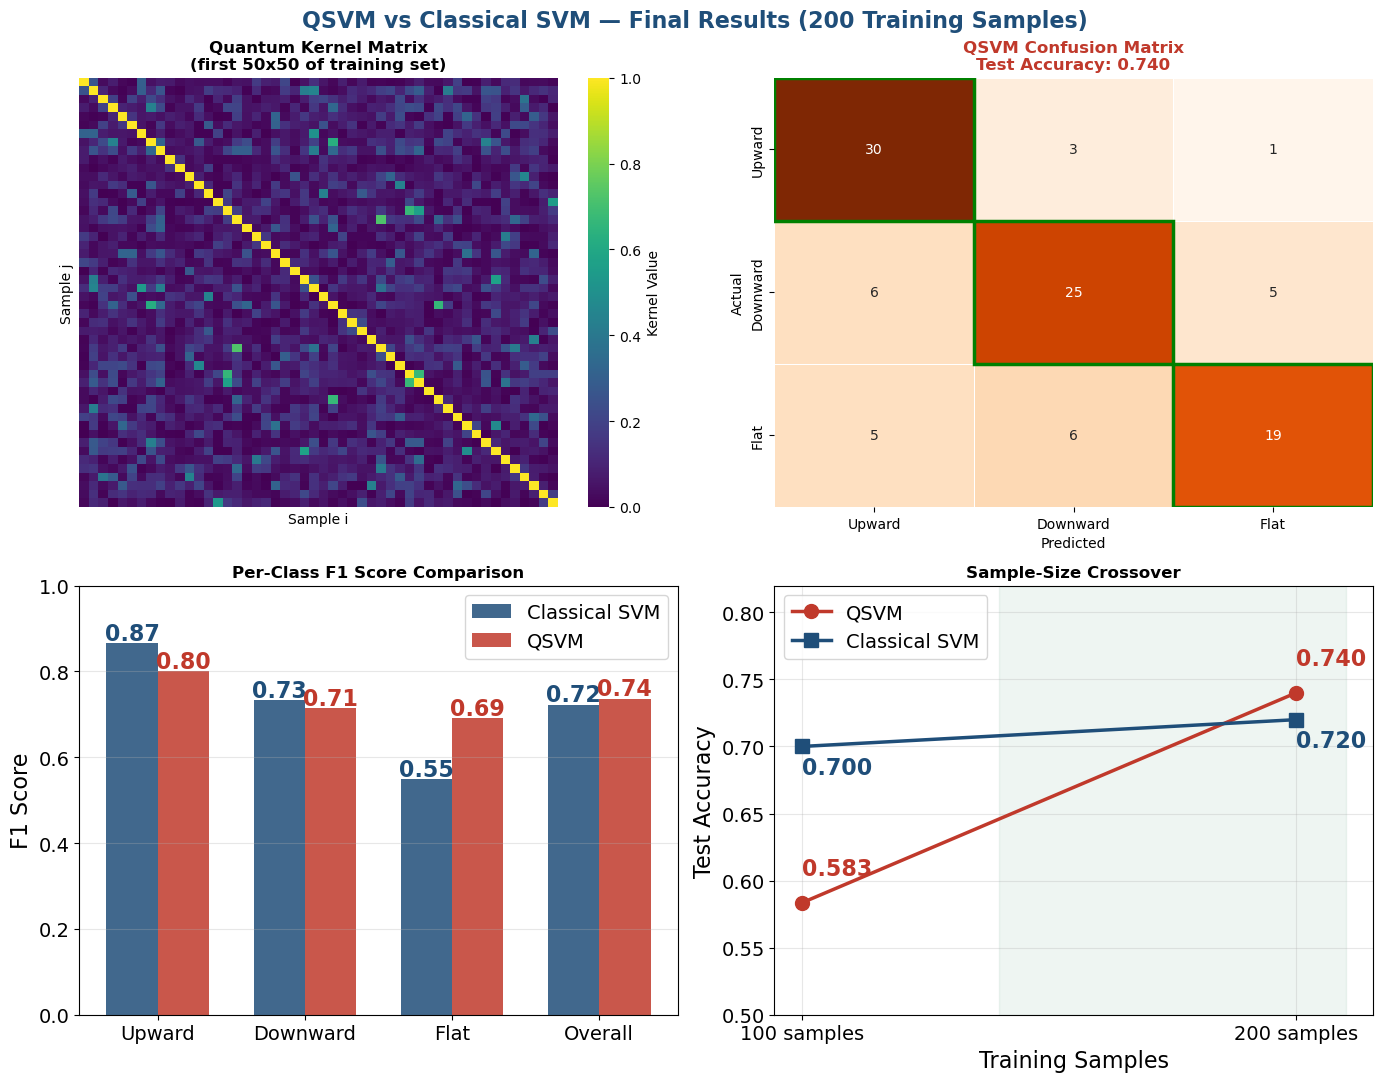

Figure saved as qsvm_results.png


In [20]:
# Final results figure: 2x2 grid summarizing QSVM vs classical SVM at 200 samples
# Plot 1: kernel matrix heatmap | Plot 2: QSVM confusion matrix
# Plot 3: per-class F1 comparison | Plot 4: accuracy crossover by sample size

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("QSVM vs Classical SVM — Final Results (200 Training Samples)",
             fontsize=16, fontweight="bold", color="#1F4E79")

# Class label names used across all subplots
class_names = ["Upward", "Downward", "Flat"]


# ── Plot 1: Kernel Matrix Heatmap ────────────────────────────────

# Show the first 50x50 block of the training kernel matrix
# A healthy kernel has bright diagonal (k(x,x)~1) and varied off-diagonal structure
# Block patterns indicate the kernel is grouping similar samples together
ax = axes[0, 0]
sns.heatmap(K_train_200[:50, :50], cmap="viridis", ax=ax,
            xticklabels=False, yticklabels=False,
            cbar_kws={"label": "Kernel Value"})
ax.set_title("Quantum Kernel Matrix\n(first 50x50 of training set)", fontweight="bold")
ax.set_xlabel("Sample i")
ax.set_ylabel("Sample j")


# ── Plot 2: Confusion Matrices ───────────────────────────────────

# Compute raw confusion matrices for both models
ax = axes[0, 1]
cm_q  = confusion_matrix(Y_te2, Y_pred7)
cm_s  = confusion_matrix(Y_te2, svm_pred7)

# Normalize QSVM confusion matrix by row (per-class recall)
# Cells show raw counts but color reflects recall percentage
cm_q_norm = cm_q.astype(float) / cm_q.sum(axis=1, keepdims=True)
sns.heatmap(cm_q_norm, annot=cm_q, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=0.5, cbar=False)

# Highlight diagonal (correct predictions) with green borders
for i in range(3):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                edgecolor="green", linewidth=2.5))
ax.set_title(f"QSVM Confusion Matrix\nTest Accuracy: {test_acc7:.3f}", fontweight="bold", color="#C0392B")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")


# ── Plot 3: Per-class F1 ─────────────────────────────────────────

# Extract per-class and weighted-average F1 scores from sklearn reports
ax = axes[1, 0]
rep_q = classification_report(Y_te2, Y_pred7, output_dict=True, zero_division=0)
rep_s = classification_report(Y_te2, svm_pred7, output_dict=True, zero_division=0)

# Build parallel F1 lists for both models in the same class order
labels_f1 = ["Upward", "Downward", "Flat", "Overall"]
f1_q = [rep_q["0"]["f1-score"], rep_q["1"]["f1-score"],
        rep_q["2"]["f1-score"], rep_q["weighted avg"]["f1-score"]]
f1_s = [rep_s["0"]["f1-score"], rep_s["1"]["f1-score"],
        rep_s["2"]["f1-score"], rep_s["weighted avg"]["f1-score"]]

# Side-by-side grouped bar chart: classical SVM on left, QSVM on right per class
x     = np.arange(len(labels_f1))
width = 0.35
b1 = ax.bar(x - width/2, f1_s, width, color="#1F4E79", alpha=0.85, label="Classical SVM")
b2 = ax.bar(x + width/2, f1_q, width, color="#C0392B", alpha=0.85, label="QSVM")

# Annotate each bar with its F1 value above the bar
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{bar.get_height():.2f}", ha="center", fontsize=16, color="#1F4E79", fontweight="bold")
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{bar.get_height():.2f}", ha="center", fontsize=16, color="#C0392B", fontweight="bold")

# Axis and legend formatting
ax.set_xticks(x, labels=labels_f1, fontsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 Score", fontsize=16)
ax.set_title("Per-Class F1 Score Comparison", fontweight="bold")
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3, axis="y")


# ── Plot 4: Sample Size Crossover ────────────────────────────────

# Pull accuracies from attempt 6 (100 samples) and attempt 7 (200 samples)
ax = axes[1, 1]
sizes    = [100, 200]
q_accs   = [test_acc6, test_acc7]
svm_accs = [svm_acc6,  svm_acc7]

# Plot QSVM vs classical SVM accuracy as a function of training size
# This is the key result: QSVM crosses over and surpasses classical at 200 samples
ax.plot(sizes, q_accs,   "o-", color="#C0392B", linewidth=2.5,
        markersize=10, label="QSVM")
ax.plot(sizes, svm_accs, "s-", color="#1F4E79", linewidth=2.5,
        markersize=10, label="Classical SVM")

# Annotate each point with its numeric accuracy
for s, q, sv in zip(sizes, q_accs, svm_accs):
    ax.annotate(f"{q:.3f}", (s, q),   xytext=(0, 20),  textcoords="offset points",
                fontsize=16, color="#C0392B", fontweight="bold")
    ax.annotate(f"{sv:.3f}", (s, sv), xytext=(0, -20), textcoords="offset points",
                fontsize=16, color="#1F4E79", fontweight="bold")

# Light green band marks the region where QSVM overtakes classical SVM
ax.axvspan(140, 210, alpha=0.07, color="#1A7A4A")

# Tick and axis formatting
ax.tick_params(axis="y", labelsize=14)
ax.set_xticks(sizes, labels=[f"{s} samples" for s in sizes], fontsize=14)
ax.set_xlabel("Training Samples", fontsize=16)
ax.set_ylabel("Test Accuracy", fontsize=16)
ax.set_title("Sample-Size Crossover", fontweight="bold")
ax.set_ylim(0.50, 0.82)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)


# Tighten layout, save high-res PNG, and display
plt.tight_layout()
plt.savefig("qsvm_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as qsvm_results.png")

# Cell 19: Classical SVM Confusion Matrix Side by Side

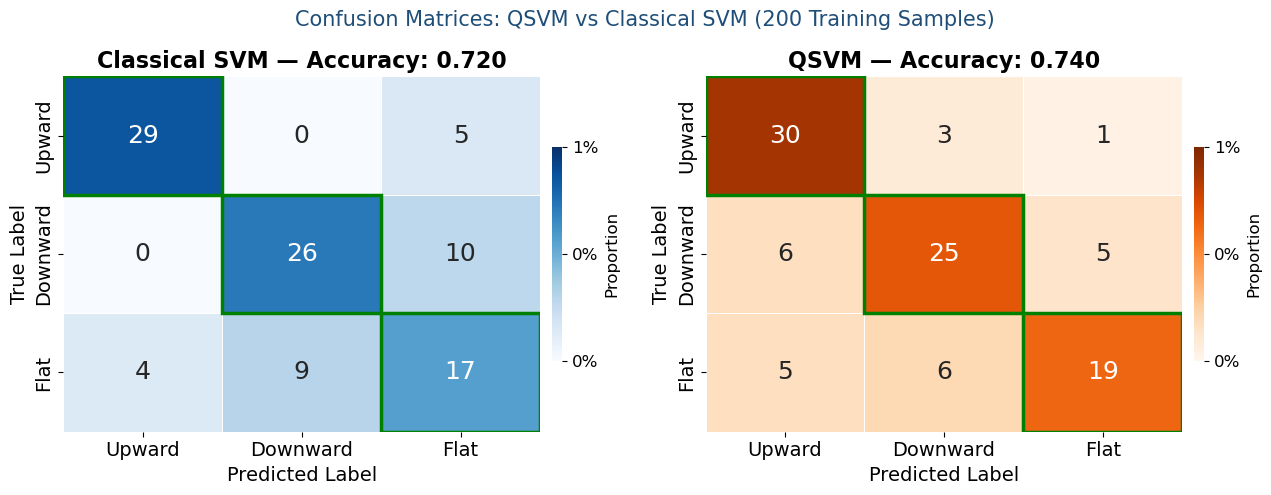

Figure saved as confusion_matrices.png


In [21]:
# Side-by-side confusion matrices for the final 200-sample comparison
# Left: classical SVM (Blues), Right: QSVM (Oranges)
# Cells show raw counts; color intensity reflects per-class recall (row-normalized)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrices: QSVM vs Classical SVM (200 Training Samples)",
             fontsize=15, color="#1F4E79")

# Loop over both axes, applying the same formatting to each panel
# Each tuple binds an axis to its confusion matrix, predictions, title, and colormap
for ax, cm, pred, title, cmap in zip(
    [ax1, ax2],
    [cm_s, cm_q],
    [svm_pred7, Y_pred7],
    [f"Classical SVM — Accuracy: {svm_acc7:.3f}", f"QSVM — Accuracy: {test_acc7:.3f}"],
    ["Blues", "Oranges"]
):
    # Row-normalize so colors reflect recall per true class
    # Annotations still show raw counts for transparency
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Heatmap with shared color scale [0, 1] so both panels are directly comparable
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, linecolor="white",
                vmin=0, vmax=1,
                annot_kws={"size": 18},
                cbar_kws={"label": "Proportion", "ticks": [0, 0.5, 1],
                          "format": "%.0f%%", "shrink": 0.6, "pad": 0.02})

    # Title and axis labels
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=14)
    ax.set_ylabel("True Label", fontsize=14)

    # Larger tick fonts for poster readability
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    # Tweak the colorbar tick and label sizes to match the rest of the figure
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.yaxis.label.set_size(12)

    # Outline the diagonal in green to highlight correct predictions
    for i in range(3):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                    edgecolor="green", linewidth=2.5))

# Tighten layout, save at high DPI for print, and display
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved as confusion_matrices.png")

# Cell 20: Final Summary Print

In [22]:
# Final comparison table summarizing all three models on the test set

# Header bar and column labels
print("=" * 65)
print(f"{'Model':<22} {'Val Acc':<12} {'Test Acc':<12} {'Test F1'}")
print("=" * 65)

# Row 1: classical SVM baseline (no validation accuracy was tracked)
print(f"{'Classical SVM':<22} {'—':<12} {svm_acc7:<12.3f} {svm_f17:.3f}")

# Row 2: QSVM with 100 training samples (attempt 6, partial success)
print(f"{'QSVM (100 samples)':<22} {val_acc6:<12.3f} {test_acc6:<12.3f} {test_f16:.3f}")

# Row 3: QSVM with 200 training samples (attempt 7, headline result)
print(f"{'QSVM (200 samples)':<22} {val_acc7:<12.3f} {test_acc7:<12.3f} {test_f17:.3f}")
print("=" * 65)

# Highlight the QSVM advantage at 200 samples in absolute terms
print(f"\nQSVM gain over Classical SVM (200 samples):")
print(f"  Accuracy : +{test_acc7 - svm_acc7:.3f}")
print(f"  F1 Score : +{test_f17  - svm_f17:.3f}")

# Print the full attempt log so the final table appears alongside the summary
show_summary()

Model                  Val Acc      Test Acc     Test F1
Classical SVM          —            0.720        0.723
QSVM (100 samples)     0.650        0.583        0.579
QSVM (200 samples)     0.800        0.740        0.736

QSVM gain over Classical SVM (200 samples):
  Accuracy : +0.020
  F1 Score : +0.014

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.239-0.288. |          |
|    |                |eta=0.04, 20 epochs, 1000 shots.  |No learning trend. Shot noise     |          |
|    |                |         